In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

def load_benchmarks(files_dict):
    dfs = []
    for version_name, file_path in files_dict.items():
        df = pd.read_csv(file_path)
        df['version'] = version_name
        
        df['relative_range'] = df['fairness_max_min_ratio']
            
        dfs.append(df)
        
    return pd.concat(dfs, ignore_index=True)

experiments = {
    # "Baseline": "benchmark_results_before_improvement.csv",
    # "Interroute Moves": "benchmark_results_no_value_increase.csv",
    # "Optimizing (Max-Min)/Min": "benchmark_results.csv",
    "Baseline": "baseline_SPB.csv",
    "Annealing": "annealing_SPB.csv",
    "Rebalancing": "rebalancing_SPB.csv",
}
experiments = {k: "../data/SPB/statistics/" + v for k, v in experiments.items()}

df = load_benchmarks(experiments)
print(f"Loaded {len(df)} total problem instances across {len(experiments)} versions.")
df.head()

Loaded 60 total problem instances across 3 versions.


,problem_id,execution_time_sec,total_distance,total_time,fairness_gini,fairness_max_min_diff,fairness_max_min_ratio,fairness_std_dev,agents_used,min_distance,max_distance,AON,ST,max_iter,time_limit,version,relative_range
0,8,15.029971,9267,69267,0.350401,2925,7.964286,988.208775,6,420,3345,5,0.025,300,8,Baseline,7.964286
1,17,12.769734,10770,70770,0.369236,3595,10.032663,1205.108432,6,398,3993,5,0.025,300,8,Baseline,10.032663
2,18,13.306497,10227,70227,0.362619,3218,9.167513,1107.043171,6,394,3612,5,0.025,300,8,Baseline,9.167513
3,5,15.079562,9538,69538,0.332390,2819,8.047500,943.398938,6,400,3219,5,0.025,300,8,Baseline,8.047500
4,3,13.493203,10007,70007,0.328487,2765,7.678744,974.074504,6,414,3179,5,0.025,300,8,Baseline,7.678744


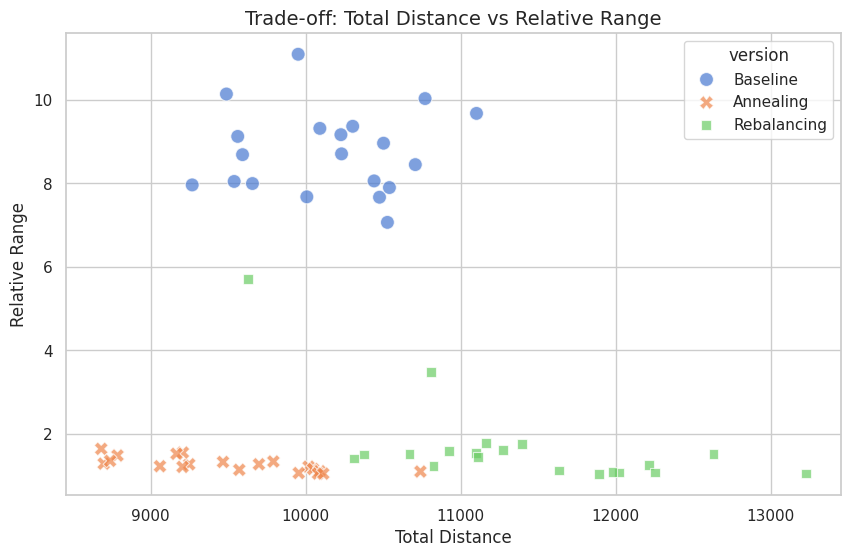

In [32]:
def scatterplot(df, x_metric='total_distance', y_metric='fairness_gini'):
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df, 
        x=x_metric, 
        y=y_metric, 
        hue='version', 
        style='version',
        s=100, alpha=0.7
    )
    
    plt.title(f"Trade-off: {x_metric.replace('_', ' ').title()} vs {y_metric.replace('_', ' ').title()}", fontsize=14)
    plt.xlabel(x_metric.replace('_', ' ').title())
    plt.ylabel(y_metric.replace('_', ' ').title())
    plt.show()

scatterplot(df, x_metric='total_distance', y_metric='relative_range')

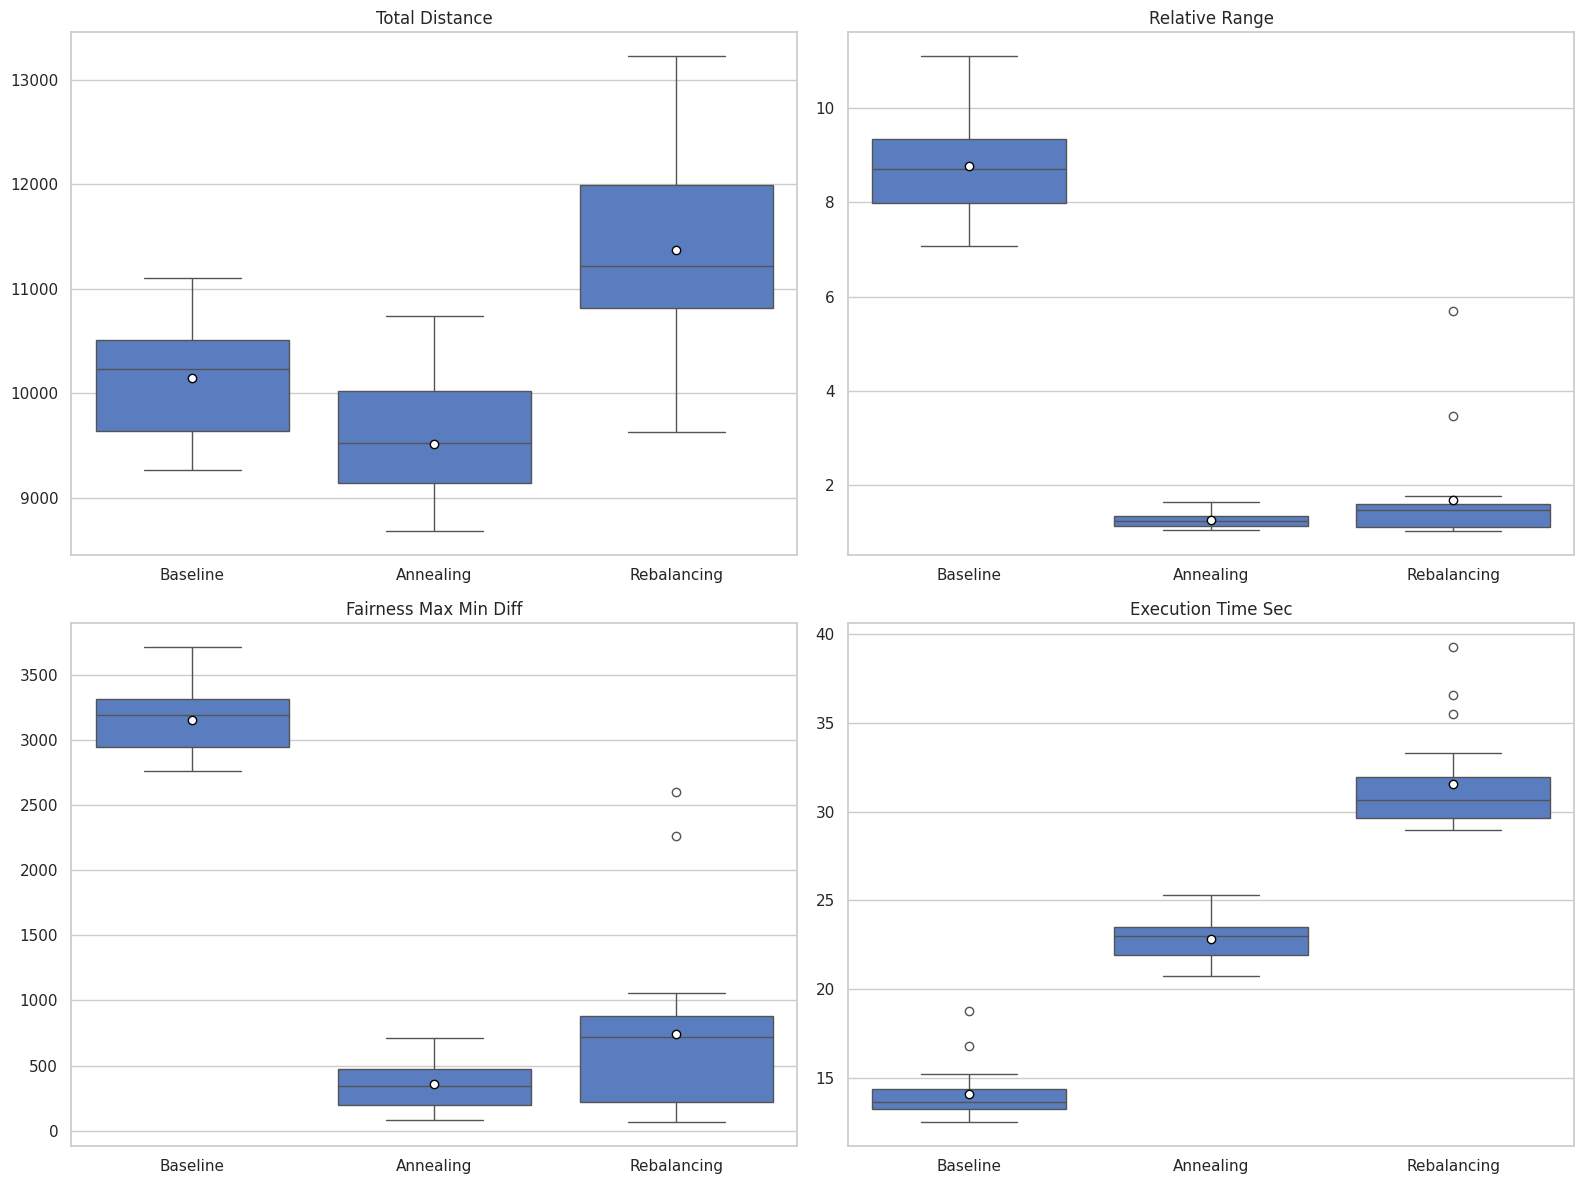

In [33]:
def compare_distributions(df, metrics: list[str], cols=2):
    rows = (len(metrics) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 6 * rows))
    axes = axes.flatten()
        
    for i, metric in enumerate(metrics):
        sns.boxplot(
            data=df, x='version', y=metric, ax=axes[i],
            showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
        )
        axes[i].set_title(metric.replace('_', ' ').title())
        axes[i].set_ylabel("")
        axes[i].set_xlabel("")
        
    plt.tight_layout()
    plt.show()

compare_distributions(df, ['total_distance', 'relative_range', 'fairness_max_min_diff', 'execution_time_sec'])

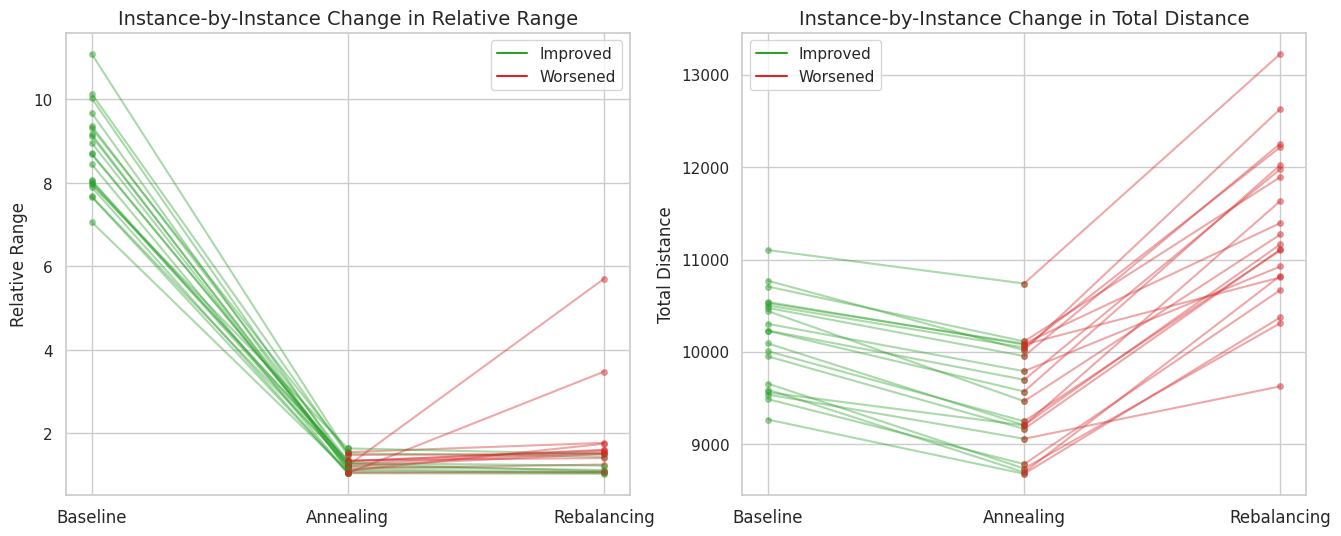

In [34]:
def plot_instance_slopes(df, metrics, versions=None, cols=2):   
    rows = (len(metrics) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 6 * rows))
    axes = axes.flatten()

    for metric_idx, metric in enumerate(metrics):
        ax = axes[metric_idx]
        pivot_df = df.pivot(index='problem_id', columns='version', values=metric)
        if versions is None:
            versions = list(pivot_df.columns)
        for i in range(len(versions) - 1):
            
            v1, v2 = versions[i], versions[i + 1]
            
            
            for index, row in pivot_df.iterrows():
                y1, y2 = row[v1], row[v2]
                if pd.isna(y1) or pd.isna(y2): continue
                    
                color = '#2ca02c' if y2 < y1 else '#d62728'
                    
                ax.plot([i + 1, i + 2], [y1, y2], marker='o', markersize=4, color=color, alpha=0.4, linewidth=1.5)
                
        
        ax.set_xticks(range(1, len(versions) + 1), versions, fontsize=12)
        ax.set_ylabel(metric.replace('_', ' ').title())
        ax.set_title(f"Instance-by-Instance Change in {metric.replace('_', ' ').title()}", fontsize=14)
        
        ax.legend(handles=[
            mlines.Line2D([], [], color='#2ca02c', label='Improved'),
            mlines.Line2D([], [], color='#d62728', label='Worsened')
        ])
    
    plt.show()

plot_instance_slopes(df, metrics=['relative_range', 'total_distance'], versions=['Baseline', 'Annealing', 'Rebalancing'])